In [1]:
import json
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from typing import Literal, Union, List
import os

In [92]:
# the structure of trajectory relevant data in the JSON file is as follows:
# {
#     "tracks": [
#         {
#             "mode": "person",
#             "frames": [
#                 {"frame_num": 0, "time_sec": 0.0, "projected_point": [1.0, 2.0], "smooth_projected_point": [1.1, 2.1]},
#                 {"frame_num": 1, "time_sec": 0.033, "projected_point": [1.5, 2.5], "smooth_projected_point": [1.6, 2.6]},
#             ],
#         },
#         {
#             "mode": "vehicle-pos",
#             "frames": [
#                 {"frame_num": 0, "time_sec": 0.0, "projected_point": [1.0, 2.0], "smooth_projected_point": [1.1, 2.1]},
#                 {"frame_num": 1, "time_sec": 0.033, "projected_point": [1.5, 2.5], "smooth_projected_point": [1.6, 2.6]},
#             ],
#         },
#     ],
#     "projected_polygon": [
#         [1.0, 2.0],
#         [1.5, 2.5],
#         [2.0, 3.0],
#         [1.0, 2.0],
#     ]
# }

# the polygon refers to the crosswalk area
# the points are transformed to a common coordinate system, so they can be plotted together
# the centroid of the polygon is the center of the crosswalk area
# the unit of the coordinates is in meters

In [107]:
def plot_polygon_and_lines_from_json(
    json_file: str,
    line_number: Union[List[int], None] = None,
    vehicle_line_number: Union[List[int], None] = None,
    mode: Literal["raw", "smoothed"] = "smoothed",
    smooth_trajectories: bool = False,
    save_fig: bool = False,
):

    with open(json_file, "r") as f:
        data = json.load(f)

    points = data.get("projected_polygon", [])
    if not points:
        print("No points found in the JSON file.")
        return

    tracks = data.get("tracks", [])
    person_tracks = [track for track in tracks if track.get("mode") == "person"]
    vehicle_tracks = [track for track in tracks if track.get("mode") == "vehicle-pos"]

    # Polygon
    x_coords = [point[0] for point in points] + [points[0][0]]
    y_coords = [point[1] for point in points] + [points[0][1]]

    plt.figure(figsize=(6, 6))

    # Plot polygon
    plt.plot(x_coords, y_coords, marker="o", label="Crosswalk Polygon", color="black")

    # If no specific indices are provided, plot all available tracks.
    person_indices = range(len(person_tracks)) if line_number is None else line_number
    vehicle_indices = (
        range(len(vehicle_tracks)) if vehicle_line_number is None else vehicle_line_number
    )

    # Plot person line(s)
    for ln in person_indices:
        if 0 <= ln < len(person_tracks):
            frames = person_tracks[ln].get("frames", [])
            if mode == "smoothed":
                line_x_coords = [frame["smooth_projected_point"][0] for frame in frames]
                line_y_coords = [frame["smooth_projected_point"][1] for frame in frames]
            else:
                line_x_coords = [frame["projected_point"][0] for frame in frames]
                line_y_coords = [frame["projected_point"][1] for frame in frames]

            if smooth_trajectories:
                smoothed_x = (
                    savgol_filter(line_x_coords, 50, 2)
                    if len(line_x_coords) >= 5
                    else line_x_coords
                )
                smoothed_y = (
                    savgol_filter(line_y_coords, 50, 2)
                    if len(line_y_coords) >= 5
                    else line_y_coords
                )
                plt.plot(
                    smoothed_x,
                    smoothed_y,
                    label=f"Smoothed Pedestrian {ln}",
                    linestyle="--",
                )
            else:
                plt.plot(line_x_coords, line_y_coords, label=f"Pedestrian {ln}")

    # Plot vehicle line(s)
    for ln in vehicle_indices:
        if 0 <= ln < len(vehicle_tracks):
            frames = vehicle_tracks[ln].get("frames", [])
            if mode == "smoothed":
                line_x_coords = [frame["smooth_projected_point"][0] for frame in frames]
                line_y_coords = [frame["smooth_projected_point"][1] for frame in frames]
            else:
                line_x_coords = [frame["projected_point"][0] for frame in frames]
                line_y_coords = [frame["projected_point"][1] for frame in frames]

            if smooth_trajectories:
                smoothed_x = (
                    savgol_filter(line_x_coords, 50, 2)
                    if len(line_x_coords) >= 5
                    else line_x_coords
                )
                smoothed_y = (
                    savgol_filter(line_y_coords, 50, 2)
                    if len(line_y_coords) >= 5
                    else line_y_coords
                )
                plt.plot(
                    smoothed_x,
                    smoothed_y,
                    label=f"Smoothed Vehicle {ln}",
                    linestyle="--",
                )
            else:
                plt.plot(line_x_coords, line_y_coords, label=f"Vehicle {ln}")

    # standardize the plot
    plt.axis("equal")
    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.title(os.path.basename(json_file).replace(".json", ""))
    plt.grid()
    plt.axis("equal")
    # plt.legend()
    plt.show()
    if save_fig:
        path = os.path.basename(json_file).replace(".json", ".png")
        plt.savefig(path, dpi=300)

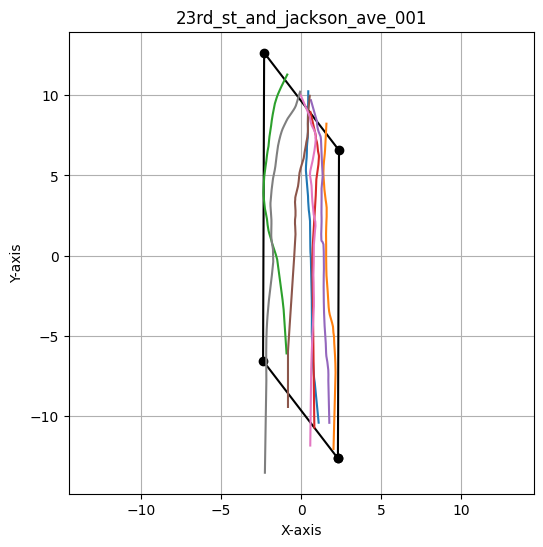

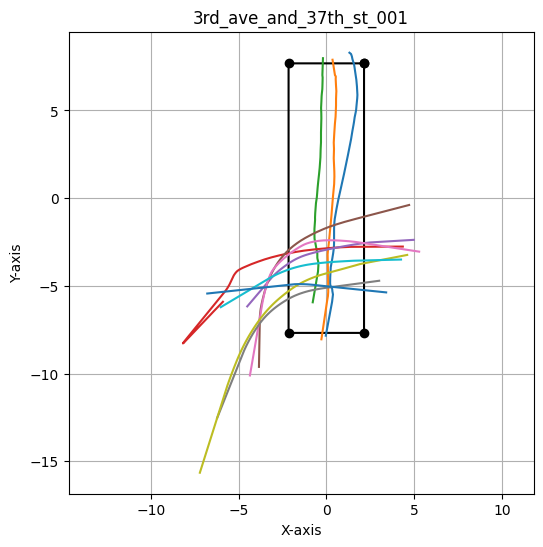

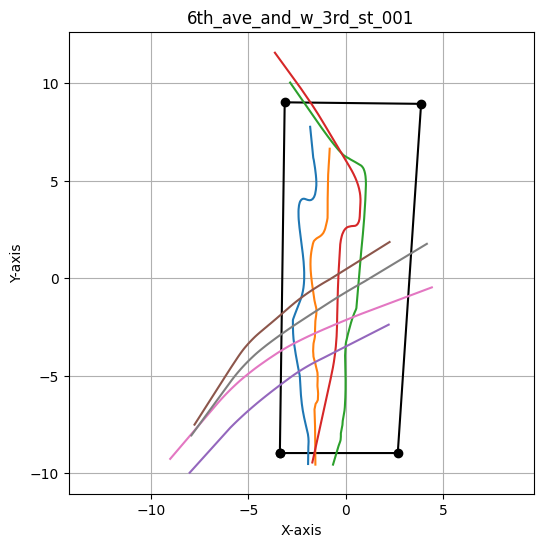

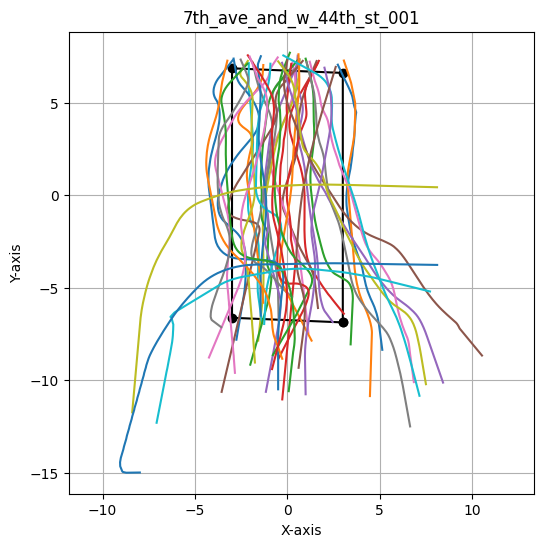

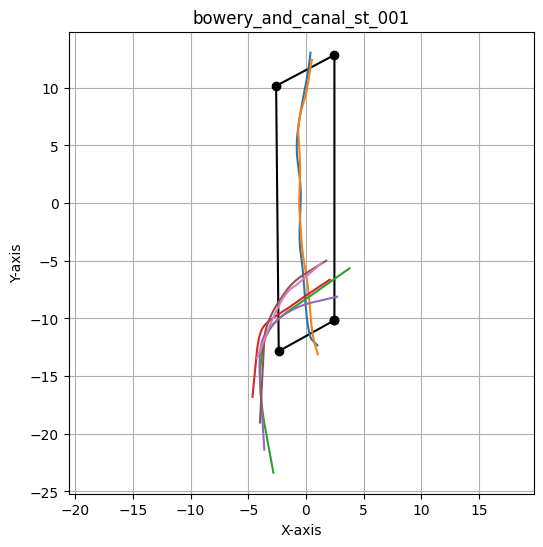

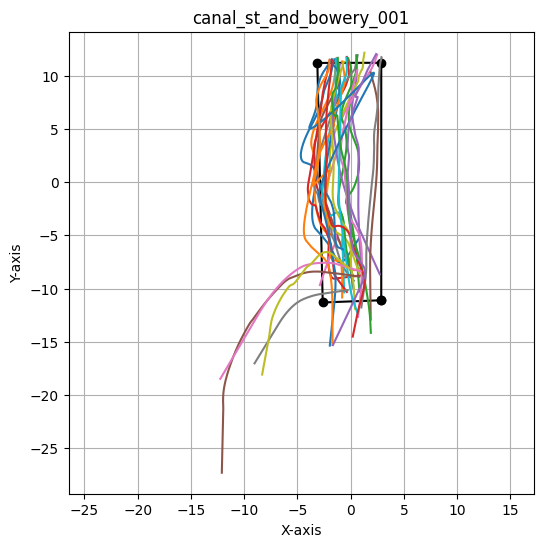

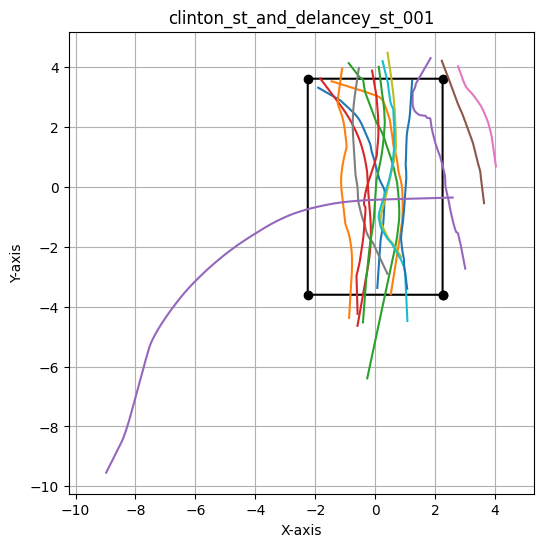

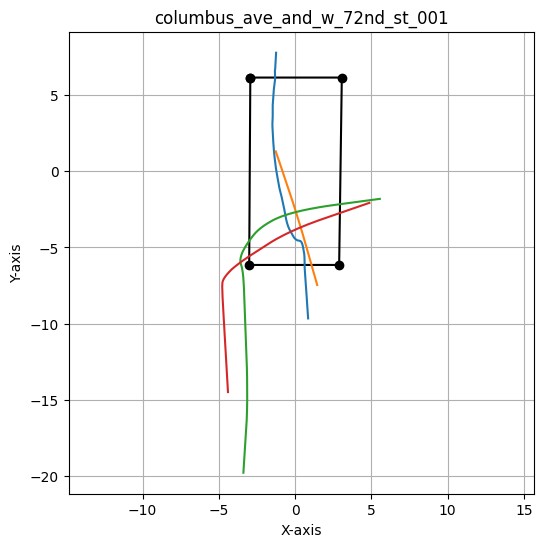

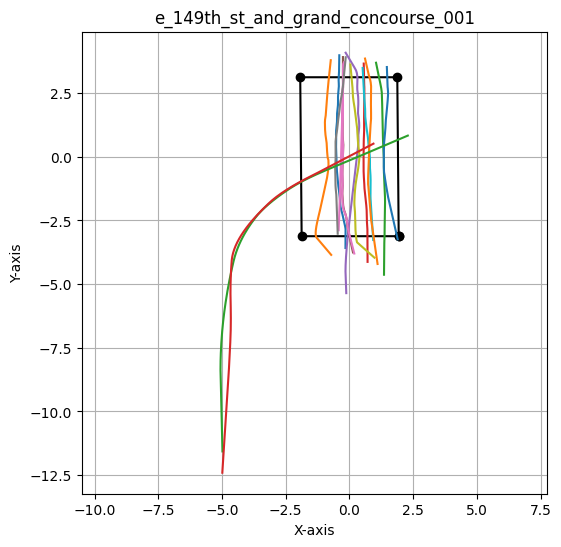

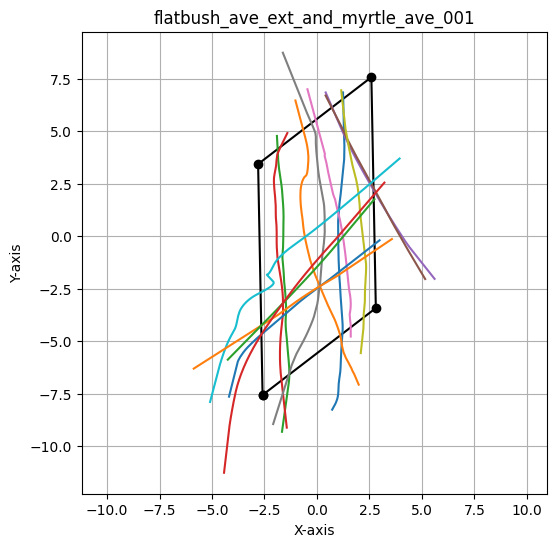

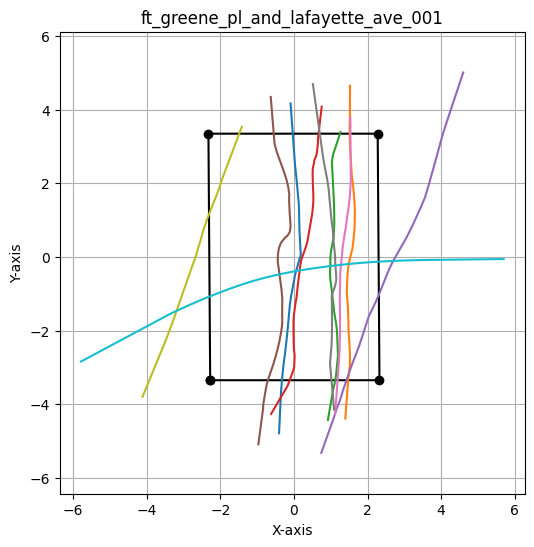

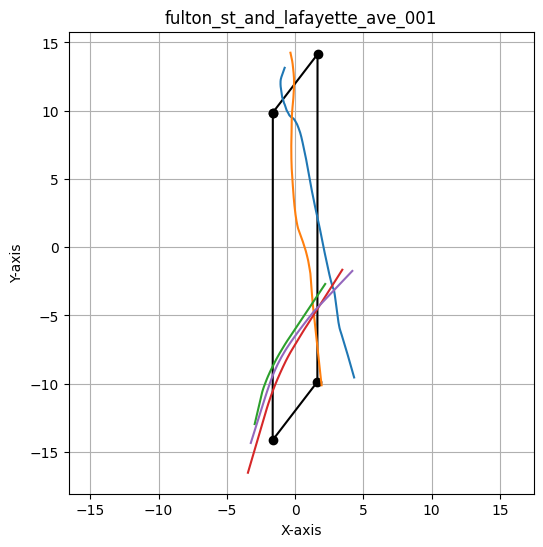

No points found in the JSON file.


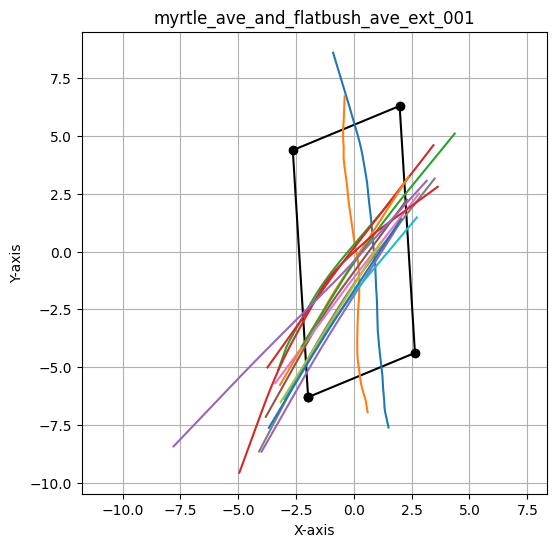

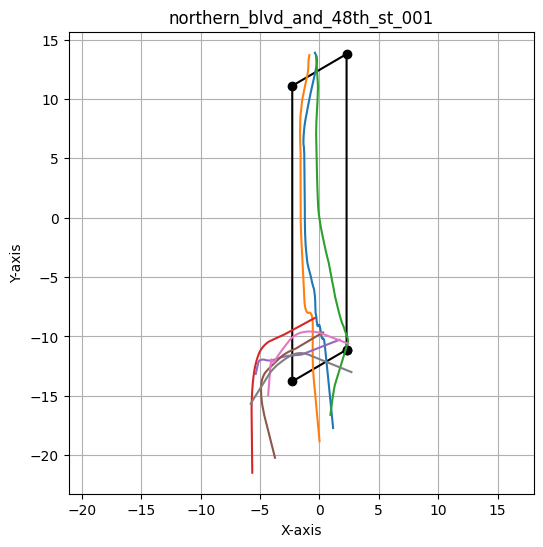

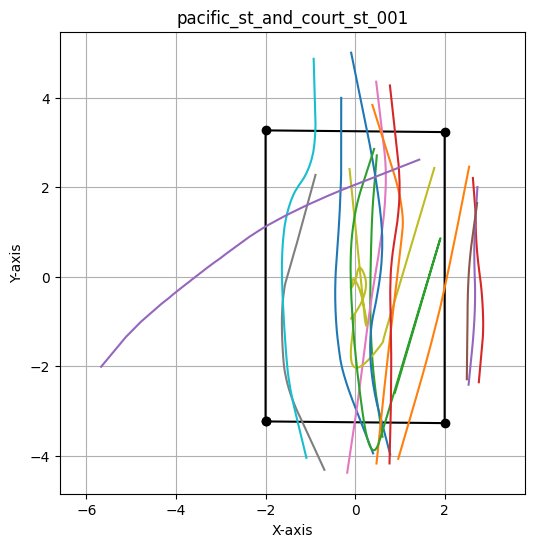

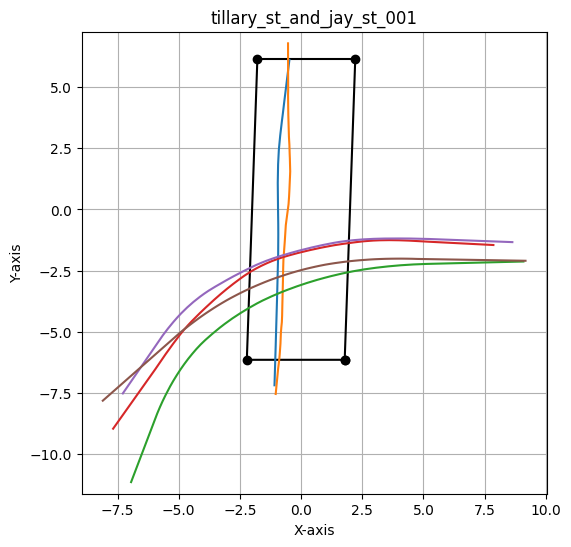

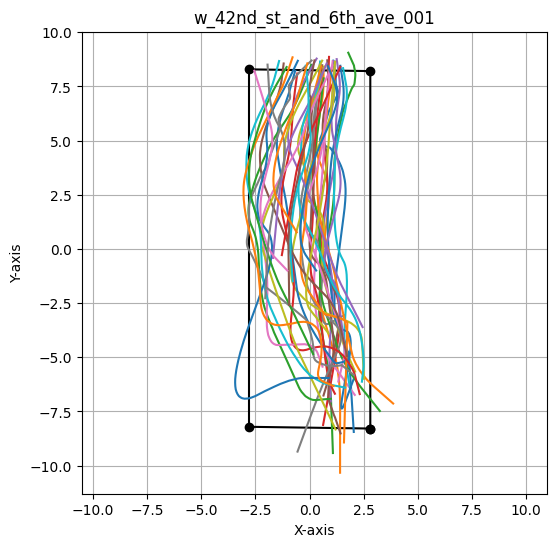

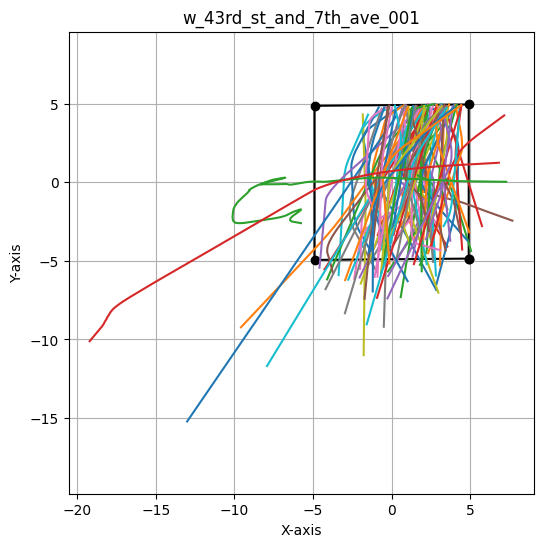

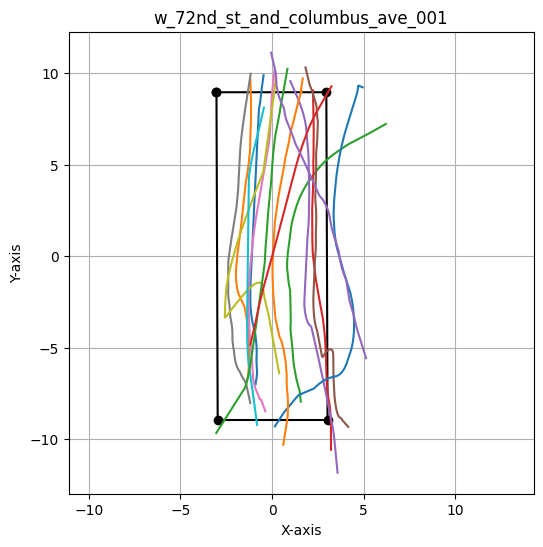

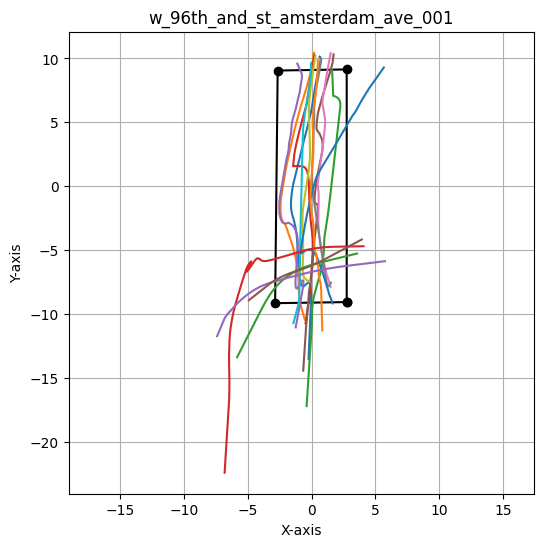

In [108]:
for intersection in [
    "23rd_st_and_jackson_ave",
    "3rd_ave_and_37th_st",
    "6th_ave_and_w_3rd_st",
    "7th_ave_and_w_44th_st",
    "bowery_and_canal_st",
    "canal_st_and_bowery",
    "clinton_st_and_delancey_st",
    "columbus_ave_and_w_72nd_st",
    "e_149th_st_and_grand_concourse",
    "flatbush_ave_ext_and_myrtle_ave",
    "ft_greene_pl_and_lafayette_ave",
    "fulton_st_and_lafayette_ave",
    "jackson_ave_and_23rd_st",
    "myrtle_ave_and_flatbush_ave_ext",
    "northern_blvd_and_48th_st",
    "pacific_st_and_court_st",
    "tillary_st_and_jay_st",
    "w_42nd_st_and_6th_ave",
    "w_43rd_st_and_7th_ave",
    "w_72nd_st_and_columbus_ave",
    "w_96th_and_st_amsterdam_ave"
]:
    
    plot_polygon_and_lines_from_json(
        f"C:/Users/abhis/Box/CUSP_Capstone_2025/Videos/{intersection}/{intersection}_001.json",
        smooth_trajectories=False,
    )